<a href="https://colab.research.google.com/github/Vishal-Mungal/NNDLPRACTICAL/blob/main/NNDL_Pr7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q tensorflow opencv-python matplotlib
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import numpy as np

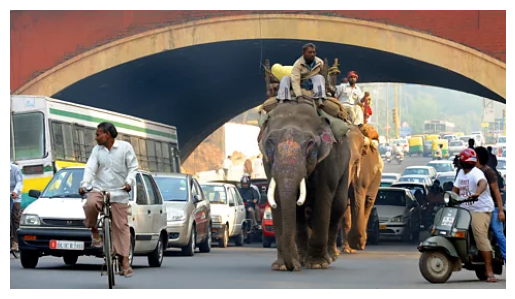

In [7]:
image = cv2.imread("cv.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.axis("off")
plt.show()

In [8]:
model = tf.saved_model.load(
    tf.keras.utils.get_file(
        fname='ssd_mobilenet_v2',
        origin='https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2?tf-hub-format=compressed',
        untar=True
    )
)

23313757/23313757 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


prepare input image

In [9]:
input_tensor = tf.convert_to_tensor(image)
input_tensor=input_tensor[tf.newaxis,...]

perform object detection

In [10]:
detections=model(input_tensor)

In [17]:
print(detections.keys())

dict_keys(['raw_detection_boxes', 'detection_multiclass_scores', 'detection_classes', 'detection_boxes', 'raw_detection_scores', 'num_detections', 'detection_anchor_indices', 'detection_scores'])


In [11]:
boxes = detections["detection_boxes"][0].numpy()
classes = detections["detection_classes"][0].numpy().astype(int)
scores = detections["detection_scores"][0].numpy()

In [12]:
class_names = {
    1: "person",
    2: "bicycle",
    3: "car",
    4: "motorcycle",
    5: "bus",
    6: "traffic light",
    7: "stop sign",
    8: "parking meter",
    9: "bench",
    10: "bird",
    11: "dog",
    12: "elephant",
}

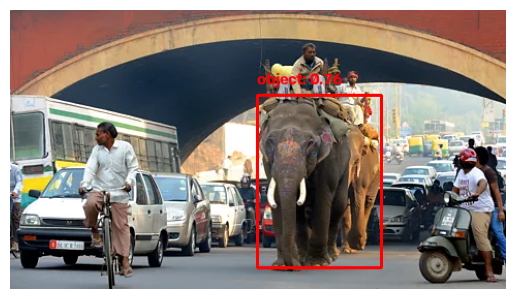

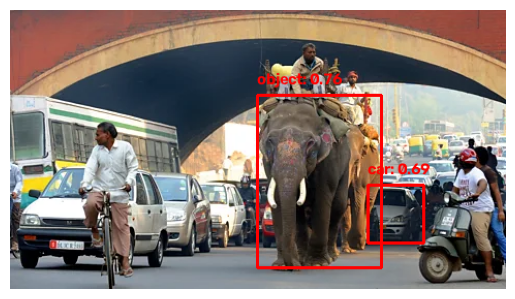

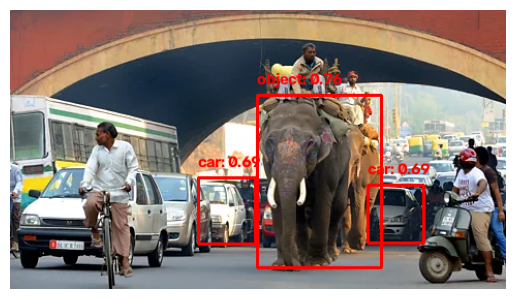

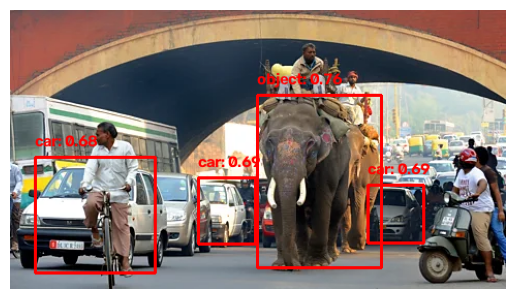

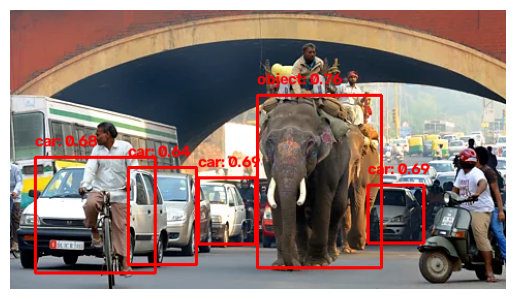

In [25]:
image_copy=image.copy()
height,width,_ = image_copy.shape
for i in range(5):
  if scores[i] > 0.5:
    ymin, xmin, ymax, xmax = boxes[i]

    start_point = (int(xmin * width), int(ymin * height))
    end_point = (int(xmax * width), int(ymax * height))

    cv2.rectangle(image_copy, start_point, end_point, (255, 0, 0), 2)
    label = class_names.get(classes[i], "object")
    confidence = scores[i]
    text = f"{label}: {confidence:.2f}"
    cv2.putText(image_copy, text, (start_point[0], start_point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    plt.imshow(image_copy)
    plt.axis("off")
    plt.show()




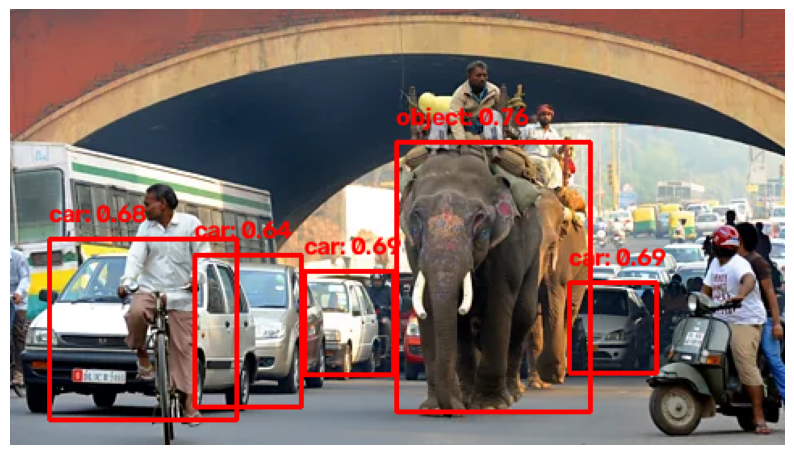

In [26]:
plt.figure(figsize=(10, 9))
plt.imshow(image_copy)
plt.axis("off")
plt.show()